# AmanLeb — Classical ML Baseline with Logistic Regression

This notebook develops the first machine learning model for the AmanLeb project.

The cleaned SMS messages are represented numerically using **TF-IDF (Term Frequency–Inverse Document Frequency)** and classified into three categories:

- `ham`
- `spam`
- `smishing`

A Logistic Regression classifier is used as the classical machine learning baseline.

The main stages of this notebook are:

1. Define the input features (`X`) and target labels (`y`).
2. Split the dataset into training, validation, and test sets.
3. Fit TF-IDF using only the training data to prevent data leakage.
4. Transform the training, validation, and test messages into numerical feature vectors.
5. Train a Logistic Regression classifier.
6. Evaluate the model using accuracy, precision, recall, F1-score, and a confusion matrix.
7. Analyze classification errors, with particular attention to the minority Spam and Smishing classes.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('Dataset_5971_clean.csv')

In [ ]:
df.head()

,LABEL,TEXT,URL,EMAIL,PHONE
0,ham,Your opinion about me? 1. Over 2. Jada 3. Kusr...,no,no,no
1,ham,What's up? Do you want me to come online? If y...,no,no,no
2,ham,So u workin overtime nigpun?,no,no,no
3,ham,"Also sir, i sent you an email about how to log...",no,no,no
4,smishing,Please Stay At Home. To encourage the notion o...,no,no,no


In [ ]:
df.shape


(5947, 5)

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5947 entries, 0 to 5946
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   LABEL   5947 non-null   str  
 1   TEXT    5947 non-null   str  
 2   URL     5947 non-null   str  
 3   EMAIL   5947 non-null   str  
 4   PHONE   5947 non-null   str  
dtypes: str(5)
memory usage: 232.4 KB


In [ ]:
X = df['TEXT']
y = df['LABEL']

## 2. Train, Validation, and Test Split

The cleaned dataset is divided into three independent subsets:

- **Training set (70%)** — used to learn the TF-IDF representation and Logistic Regression parameters.
- **Validation set (15%)** — used to evaluate and tune modeling decisions.
- **Test set (15%)** — kept untouched until the final model evaluation.

Because the dataset is imbalanced, stratified splitting is used to preserve approximately the same Ham, Spam, and Smishing proportions across all three subsets.

A fixed random state is used to make the experiment reproducible.

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

In [ ]:
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

In [ ]:
print("Training samples:", len(X_train))
print("Validation samples:", len(X_val))
print("Test samples:", len(X_test))

print("\nTotal:", len(X_train) + len(X_val) + len(X_test))

Training samples: 4162
Validation samples: 892
Test samples: 893

Total: 5947


In [ ]:
for name, labels in [
    ('Full Dataset', y),
    ('Training', y_train),
    ('Validation', y_val),
    ('Test', y_test)
]:
    print(f"\n{name}:")
    print((labels.value_counts(normalize=True) * 100).round(2))


Full Dataset:
LABEL
ham         81.28
smishing    10.53
spam         8.19
Name: proportion, dtype: float64

Training:
LABEL
ham         81.28
smishing    10.52
spam         8.19
Name: proportion, dtype: float64

Validation:
LABEL
ham         81.28
smishing    10.54
spam         8.18
Name: proportion, dtype: float64

Test:
LABEL
ham         81.30
smishing    10.53
spam         8.17
Name: proportion, dtype: float64


**Conclusion:** The dataset was successfully divided into training (70%), validation (15%), and test (15%) subsets. Stratified sampling preserved the original class distribution across all three sets, ensuring that the minority Spam and Smishing classes are appropriately represented during training and evaluation.

## 3. TF-IDF Feature Extraction

Machine learning algorithms such as Logistic Regression cannot directly process raw text. Therefore, the SMS messages must first be transformed into numerical feature vectors.

For the classical machine learning baseline, **TF-IDF (Term Frequency–Inverse Document Frequency)** is used to represent the importance of words within each message.

TF-IDF assigns higher importance to terms that are frequent within a particular message but less common across the overall collection of messages. Common terms that occur in many documents receive lower importance, while more distinctive terms receive larger weights.

To prevent data leakage, the TF-IDF vectorizer is fitted **only on the training set**. The learned vocabulary and IDF statistics are then used to transform the validation and test sets without fitting on them.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [ ]:
tfidf = TfidfVectorizer()

In [ ]:
X_train_tfidf = tfidf.fit_transform(X_train)

In [ ]:
X_val_tfidf = tfidf.transform(X_val)
X_test_tfidf = tfidf.transform(X_test)

In [ ]:
print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Validation TF-IDF shape:", X_val_tfidf.shape)
print("Test TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (4162, 7843)
Validation TF-IDF shape: (892, 7843)
Test TF-IDF shape: (893, 7843)


In [ ]:
feature_names = tfidf.get_feature_names_out()

print("Number of vocabulary features:", len(feature_names))
print("\nFirst 50 features:")
print(feature_names[:50])

Number of vocabulary features: 7843

First 50 features:
['00' '000' '008704050406' '00euro' '00pm' '011' '0121' '01223585236'
 '01223585334' '0125698789' '02' '020001951238' '0207' '02072069400'
 '02073162414' '02085076972' '021' '03' '032' '03216837293' '0327884425'
 '03303800231' '03303800232' '04' '0430' '05' '050703' '0578' '06' '07'
 '07008009200' '07046744435' '07090201529' '07090298926' '07099833605'
 '07123456789' '0721072' '07732584351' '07734396839' '07734396840'
 '07742676564' '07753741225' '0776xxxxxxx' '07781482378' '07786200117'
 '078' '07808' '07808726822' '07815296484' '07821230901']


In [ ]:
print("\nSome features:")
print(feature_names[500:550])


Some features:
['3230' '326' '33' '34000' '342152' '349' '35' '350' '3510i' '3567'
 '35lakh' '365' '3650' '36504' '3680' '37' '3750' '37819' '38' '382'
 '38977148576' '398' '3aj' '3bhk' '3d' '3g' '3gbp' '3hrs' '3lions' '3lp'
 '3miles' '3milion' '3mins' '3pound' '3qxj9' '3rd' '3ss' '3uz' '3wks'
 '3xx' '40' '400' '402' '4041' '40533' '40gb' '40mph' '4150' '41685'
 '41782']


## 4. Logistic Regression Baseline

After transforming the SMS messages into TF-IDF vectors, a multinomial Logistic Regression classifier is trained on the training set.

The model learns weights for the TF-IDF features that indicate how strongly different words and tokens contribute to the Ham, Spam, and Smishing classes.

The initial model is intentionally kept simple and uses the default configuration as a baseline. Model improvements will only be introduced after evaluating this baseline on the validation set.

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

In [ ]:
model.fit(X_train_tfidf, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [ ]:
print("Classes:", model.classes_)
print("Coefficient matrix shape:", model.coef_.shape)

Classes: ['ham' 'smishing' 'spam']
Coefficient matrix shape: (3, 7843)


In [ ]:
val_predictions = model.predict(X_val_tfidf)

## 5. Baseline Validation Evaluation

The trained Logistic Regression model is evaluated on the validation set, which was not used during model training.

Because the dataset is imbalanced, overall accuracy is not sufficient to evaluate the classifier. Therefore, the analysis also considers class-specific precision, recall, and F1-score, together with macro and weighted averages.

Particular attention is given to the Spam and Smishing classes because failing to detect suspicious messages is more important for the AmanLeb use case than simply achieving a high overall accuracy.

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [ ]:
val_accuracy = accuracy_score(y_val, val_predictions)

print(f"Validation Accuracy: {val_accuracy:.4f}")

Validation Accuracy: 0.9507


In [ ]:
print(
    classification_report(
        y_val,
        val_predictions,
        digits=3
    )
)

              precision    recall  f1-score   support

         ham      0.959     0.999     0.978       725
    smishing      0.950     0.809     0.874        94
        spam      0.842     0.658     0.738        73

    accuracy                          0.951       892
   macro avg      0.917     0.822     0.863       892
weighted avg      0.948     0.951     0.948       892



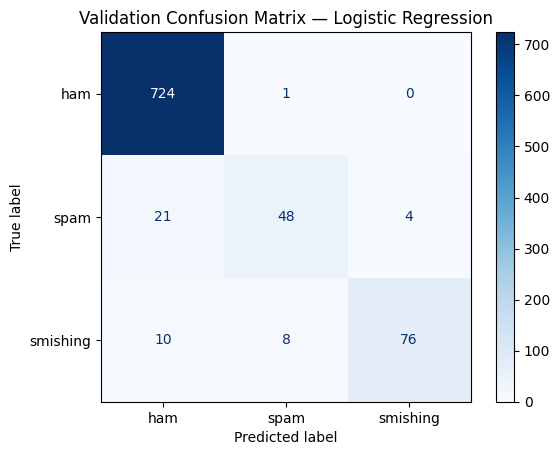

In [ ]:
ConfusionMatrixDisplay.from_predictions(
    y_val,
    val_predictions,
    labels=['ham', 'spam', 'smishing'],
    cmap='Blues'
)

plt.title('Validation Confusion Matrix — Logistic Regression')
plt.show()

### Baseline Evaluation Conclusion

The baseline TF-IDF + Logistic Regression classifier achieved a validation accuracy of **95.07%** and a macro F1-score of **0.863**. However, the class-specific results reveal an important effect of the dataset imbalance.

The model performs extremely well on the majority Ham class, achieving 99.9% recall. Smishing performance is also strong, with 95.0% precision and 80.9% recall. Spam is the weakest class, achieving 84.2% precision but only 65.8% recall.

The confusion matrix reveals that 21 Spam messages and 10 Smishing messages were incorrectly classified as Ham. These false-negative suspicious predictions are particularly important for AmanLeb because they could cause potentially harmful messages to be treated as legitimate.

The model therefore demonstrates high precision when identifying suspicious messages but lower recall, particularly for the minority Spam class. This suggests that class imbalance may be causing the classifier to favor the majority Ham class.

The baseline provides a strong starting point, but the next experiments should focus on improving Spam and Smishing recall without causing an excessive reduction in precision.

## 6. Error Analysis

In [ ]:
val_results = pd.DataFrame({
    'TEXT': X_val,
    'TRUE_LABEL': y_val,
    'PREDICTED_LABEL': val_predictions
})

In [ ]:
val_results.head()

,TEXT,TRUE_LABEL,PREDICTED_LABEL
3157,K.then any other special?,ham,ham
4803,You still at grand prix?,ham,ham
912,It has issues right now. Ill fix for her by to...,ham,ham
1419,"You are happy...You skype, you take pictures, ...",ham,ham
4588,I wont. So wat's wit the guys,ham,ham


In [ ]:
errors = val_results[
    val_results['TRUE_LABEL'] != val_results['PREDICTED_LABEL']
]

print("Total validation errors:", len(errors))
errors

Total validation errors: 44


,TEXT,TRUE_LABEL,PREDICTED_LABEL
5654,\tFree entry to the gr8prizes wkly comp 4 a ch...,smishing,spam
2613,you'hv completed a transaction for AUD 788.93 ...,smishing,ham
3423,goldviking (29/M) is inviting you to be his fr...,smishing,spam
4406,Fantasy Football is back on your TV. Go to Sky...,spam,ham
5940,call now 08707509020 Just 20p per min NTT Ltd...,spam,smishing
5864,Hi ya babe x u 4goten bout me?' scammers getti...,spam,ham
1132,Burger King - Wanna play footy at a top stadiu...,spam,ham
5290,"Hi this is Amy, we will be sending you a free ...",spam,ham
2965,Block Breaker now comes in deluxe format with ...,spam,ham
1485,Monthly password for wap. mobsi.com is 391784....,spam,ham


In [ ]:
smishing_as_ham = val_results[
    (val_results['TRUE_LABEL'] == 'smishing') &
    (val_results['PREDICTED_LABEL'] == 'ham')
]

print("Smishing predicted as Ham:", len(smishing_as_ham))

pd.set_option('display.max_colwidth', None)
smishing_as_ham[['TEXT']]

Smishing predicted as Ham: 10


,TEXT
2613,you'hv completed a transaction for AUD 788.93 on 06/02/17 03-27-31 pm. Please follow the link if it is not done by you http://commbank.netban
371,BMO have noticed unusual activites on your online account. You are required to verify your account details.www.97bmo.tk
4,Please Stay At Home. To encourage the notion of staying at home. All tax-paying citizens are entitled to �305.96 or more emergency refund. smsg.io/fCVbD
1981,\tDont forget you can place as many FREE Requests with 1stchoice.co.uk as you wish. For more Information call 08707808226.
5794,\tPromotion Number: 8714714 - UR awarded a City Break and could WIN a £200 Summer Shopping spree every WK. Txt STORE to 88039 . SkilGme. TsCs087147403231Winawk!Age16 £1.50perWKsub
5586,"This weeks SavaMob member offers are now accessible. Just call 08709501522 for details! SavaMob, POBOX 139, LA3 2WU. Only £1.50/week. SavaMob - offers mobile!"
1085,\tDear Voucher holder Have your next meal on us. Use the following link on your pc 2 enjoy a 2 4 1 dining experiencehttp://www.vouch4me.com/etlp/dining.asp
3414,Update_Now - 12Mths Half Price Orange line rental: 400mins...Call MobileUpd8 on 08000839402 or call2optout=J5Q
4072,Natalja (25/F) is inviting you to be her friend. Call 08718738034
606,"Congrats! 1 year special cinema pass for 2 is yours. call 09061209467 now! C Suprman V, Matrix3, StarWars3, etc all 4 FREE! bx420-ip4-5we. 150pm. Dont miss out!"


### Error Analysis Findings

Inspection of the baseline errors revealed several important patterns.

Many Smishing messages incorrectly classified as Ham still contain suspicious characteristics such as URLs, monetary rewards, promotional language, phone numbers, and calls to action. This suggests that the classifier may be biased toward predicting the majority Ham class when the textual evidence for a minority class is not sufficiently strong.

The Spam-to-Ham errors are more diverse. Some are clearly promotional messages, while others resemble ordinary conversational messages. This indicates that the boundary between Ham and Spam can sometimes be linguistically ambiguous and may also contain some annotation noise.

Several incorrectly classified messages also contain meaningful multi-word expressions such as promotional offers, calls to action, and reward-related phrases. The current TF-IDF representation uses individual words only, meaning that relationships between adjacent words are not explicitly represented.

Overall, the error analysis supports the hypothesis that class imbalance is contributing to the lower recall of the Spam and Smishing classes. The next experiment therefore introduces class weighting while keeping the TF-IDF representation unchanged.

## 7. Class-Weighted Logistic Regression

The baseline model demonstrated strong overall performance but lower recall for the minority Spam and Smishing classes. Error analysis showed that a considerable number of suspicious messages were incorrectly classified as Ham.

To investigate whether class imbalance contributes to this behavior, a second Logistic Regression model is trained using `class_weight='balanced'`.

This automatically assigns greater importance to underrepresented classes during training while assigning relatively less importance to the majority Ham class.

All other components of the experiment are kept unchanged so that the effect of class weighting can be evaluated independently.

In [ ]:
balanced_model = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight='balanced'
)

balanced_model.fit(X_train_tfidf, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

In [ ]:
balanced_val_predictions = balanced_model.predict(X_val_tfidf)

In [ ]:
balanced_val_accuracy = accuracy_score(
    y_val,
    balanced_val_predictions
)

print(f"Balanced Validation Accuracy: {balanced_val_accuracy:.4f}")

print(
    classification_report(
        y_val,
        balanced_val_predictions,
        digits=3
    )
)

Balanced Validation Accuracy: 0.9630
              precision    recall  f1-score   support

         ham      0.986     0.992     0.989       725
    smishing      0.921     0.872     0.896        94
        spam      0.784     0.795     0.789        73

    accuracy                          0.963       892
   macro avg      0.897     0.886     0.891       892
weighted avg      0.963     0.963     0.963       892



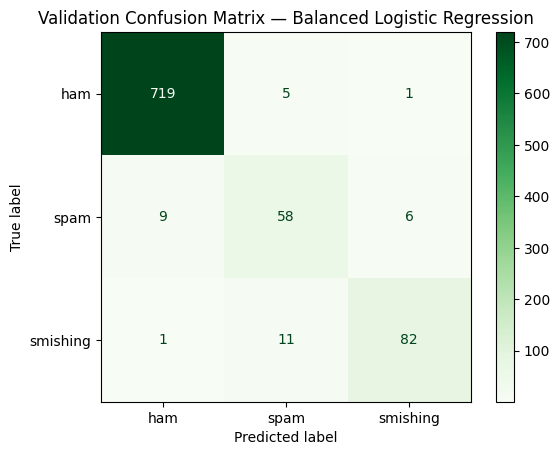

In [ ]:
ConfusionMatrixDisplay.from_predictions(
    y_val,
    balanced_val_predictions,
    labels=['ham', 'spam', 'smishing'],
    cmap='Greens'
)

plt.title('Validation Confusion Matrix — Balanced Logistic Regression')
plt.show()

In [ ]:
baseline_suspicious_as_ham = (
    ((y_val == 'spam') | (y_val == 'smishing')) &
    (val_predictions == 'ham')
).sum()

print(
    "Baseline suspicious → Ham errors:",
    baseline_suspicious_as_ham
)

Baseline suspicious → Ham errors: 31


In [ ]:
balanced_suspicious_as_ham = (
    ((y_val == 'spam') | (y_val == 'smishing')) &
    (balanced_val_predictions == 'ham')
).sum()

print(
    "Balanced suspicious → Ham errors:",
    balanced_suspicious_as_ham
)

Balanced suspicious → Ham errors: 10


### Class-Weighting Experiment Conclusion

Introducing balanced class weights significantly improved the Logistic Regression classifier.

The baseline model achieved a macro F1-score of **0.863**, while the class-weighted model increased the macro F1-score to **0.891**. Overall validation accuracy also improved from **95.1% to 96.3%**.

The largest improvement occurred in the minority classes. Spam recall increased from **65.8% to 79.5%**, while Smishing recall increased from **80.9% to 87.2%**. This improvement came with a moderate reduction in precision, indicating that the balanced model is more willing to classify uncertain messages as suspicious.

Most importantly for the AmanLeb use case, the number of suspicious messages incorrectly classified as Ham decreased from **31 to 10**. Spam-to-Ham errors decreased from 21 to 9, while Smishing-to-Ham errors decreased from 10 to only 1.

Therefore, the class-weighted Logistic Regression model provides a better tradeoff for AmanLeb. Although it produces slightly more false-positive suspicious predictions, it substantially reduces the more dangerous false negatives in which Spam or Smishing messages are treated as legitimate.

Based on the validation results, the class-weighted Logistic Regression classifier is selected as the preferred classical machine learning model.

## 8. Final Test Evaluation

After comparing the baseline and class-weighted Logistic Regression models using the validation set, the class-weighted model was selected as the preferred classical machine learning classifier.

The test set has remained completely untouched throughout model development and model selection. It is now used once to estimate how well the selected model generalizes to unseen SMS messages.

The same TF-IDF representation learned exclusively from the training data is used to transform the test messages.

In [ ]:
test_predictions = balanced_model.predict(X_test_tfidf)

In [ ]:
test_accuracy = accuracy_score(
    y_test,
    test_predictions
)

print(f"Final Test Accuracy: {test_accuracy:.4f}")

print(
    classification_report(
        y_test,
        test_predictions,
        digits=3
    )
)

Final Test Accuracy: 0.9608
              precision    recall  f1-score   support

         ham      0.993     0.988     0.990       726
    smishing      0.870     0.851     0.860        94
        spam      0.772     0.836     0.803        73

    accuracy                          0.961       893
   macro avg      0.878     0.891     0.884       893
weighted avg      0.962     0.961     0.961       893



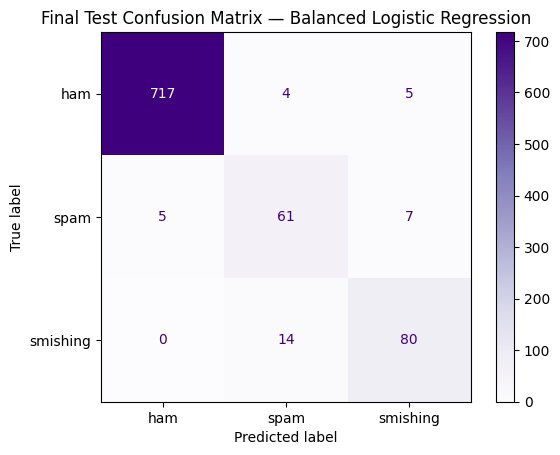

In [ ]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    test_predictions,
    labels=['ham', 'spam', 'smishing'],
    cmap='Purples'
)

plt.title('Final Test Confusion Matrix — Balanced Logistic Regression')
plt.show()

In [ ]:
test_suspicious_as_ham = (
    ((y_test == 'spam') | (y_test == 'smishing')) &
    (test_predictions == 'ham')
).sum()

print(
    "Suspicious messages predicted as Ham:",
    test_suspicious_as_ham
)

Suspicious messages predicted as Ham: 5


In [ ]:
train_predictions = balanced_model.predict(X_train_tfidf)

print(
    classification_report(
        y_train,
        train_predictions,
        digits=3
    )
)

              precision    recall  f1-score   support

         ham      1.000     0.991     0.995      3383
    smishing      0.954     0.945     0.950       438
        spam      0.896     0.982     0.937       341

    accuracy                          0.986      4162
   macro avg      0.950     0.973     0.961      4162
weighted avg      0.986     0.986     0.986      4162



In [ ]:
train_accuracy = accuracy_score(
    y_train,
    train_predictions
)

print(f"Training Accuracy:   {train_accuracy:.4f}")
print(f"Validation Accuracy: {balanced_val_accuracy:.4f}")
print(f"Test Accuracy:       {test_accuracy:.4f}")

Training Accuracy:   0.9856
Validation Accuracy: 0.9630
Test Accuracy:       0.9608


## 9. Model Interpretability

One advantage of Logistic Regression is that its predictions are relatively interpretable.

For each target class, the model learns one coefficient for every TF-IDF feature. A larger positive coefficient indicates that the presence of that token provides stronger evidence in favor of the corresponding class.

By inspecting the largest coefficients for Ham, Spam, and Smishing, we can examine which words or tokens the classifier considered most informative when making its predictions.

In [ ]:
feature_names = tfidf.get_feature_names_out()

top_n = 20

for class_index, class_name in enumerate(balanced_model.classes_):
    
    coefficients = balanced_model.coef_[class_index]
    
    top_indices = np.argsort(coefficients)[-top_n:][::-1]
    
    print(f"\nTop features for {class_name.upper()}:")
    
    for index in top_indices:
        print(
            f"{feature_names[index]:20s} "
            f"{coefficients[index]:.3f}"
        )


Top features for HAM:
me                   1.959
my                   1.869
that                 1.458
ok                   1.450
later                1.416
am                   1.337
lt                   1.328
gt                   1.322
come                 1.314
ll                   1.218
so                   1.205
can                  1.175
when                 1.160
but                  1.147
da                   1.145
how                  1.136
going                1.128
then                 1.073
got                  1.056
it                   1.044

Top features for SMISHING:
claim                3.694
call                 3.552
customer             2.855
http                 2.650
prize                2.374
awarded              2.257
won                  2.119
contact              2.099
paytm                2.058
has                  2.050
urgent               1.916
your                 1.862
delivery             1.760
com                  1.724
please               1.623
500 

In [ ]:
top_features = {}

for class_index, class_name in enumerate(balanced_model.classes_):
    
    coefficients = balanced_model.coef_[class_index]
    top_indices = np.argsort(coefficients)[-20:][::-1]
    
    top_features[class_name] = pd.DataFrame({
        'Feature': feature_names[top_indices],
        'Coefficient': coefficients[top_indices]
    })

for class_name, table in top_features.items():
    print(f"\n{class_name.upper()}")
    display(table)


HAM


,Feature,Coefficient
0,me,1.958742
1,my,1.869041
2,that,1.457596
3,ok,1.450090
4,later,1.415584
5,am,1.336690
6,lt,1.328000
7,gt,1.322497
8,come,1.313945
9,ll,1.218057



SMISHING


,Feature,Coefficient
0,claim,3.694429
1,call,3.551797
2,customer,2.854861
3,http,2.650163
4,prize,2.373511
5,awarded,2.257060
6,won,2.118959
7,contact,2.098928
8,paytm,2.058285
9,has,2.050275



SPAM


,Feature,Coefficient
0,txt,3.046888
1,win,2.260636
2,ringtone,1.967450
3,chat,1.869727
4,tone,1.861113
5,text,1.798138
6,150p,1.654694
7,stop,1.626718
8,noida,1.594900
9,50,1.461419


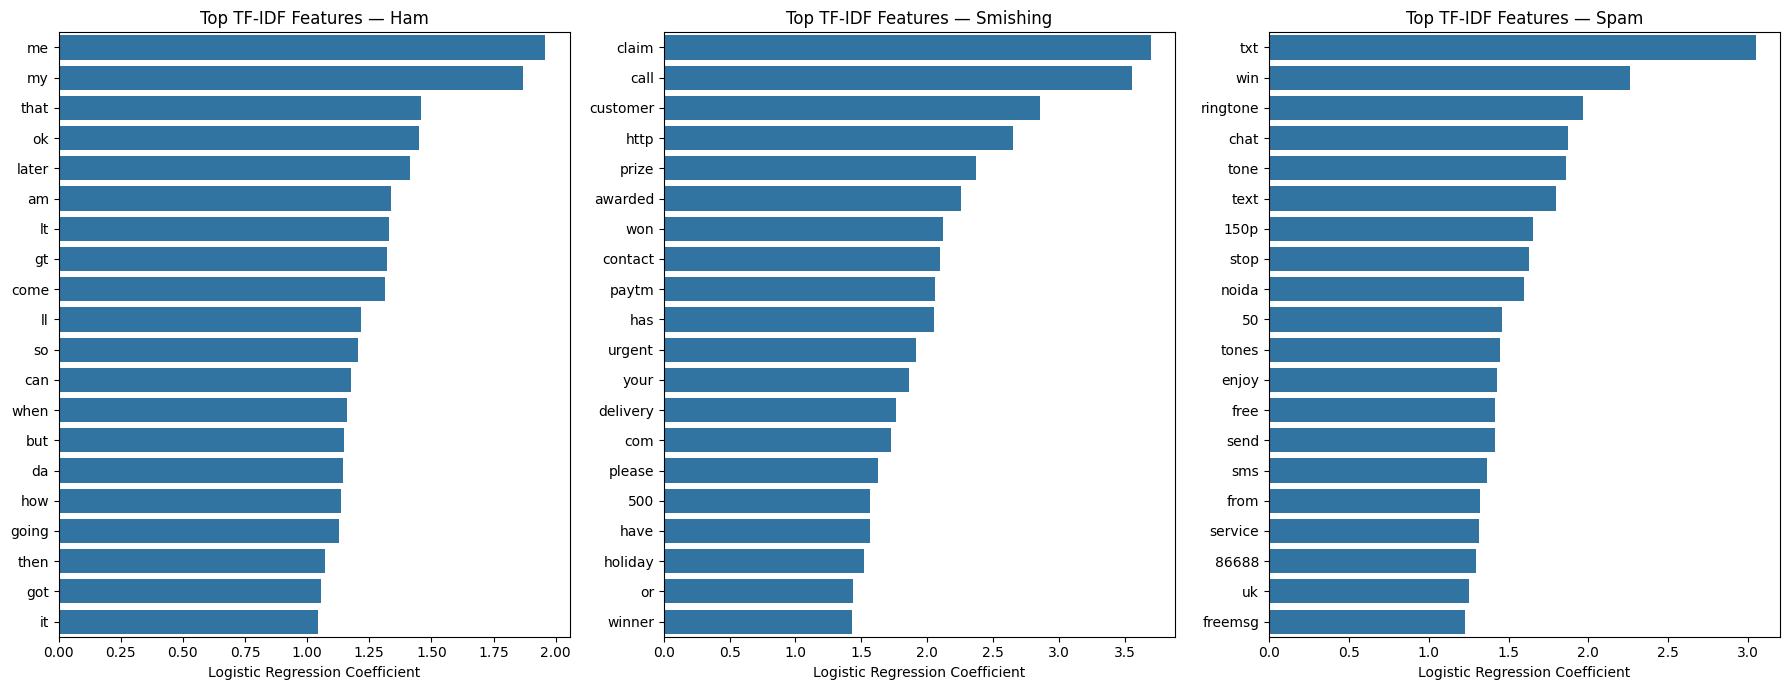

In [ ]:
fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 7)
)

for ax, (class_name, table) in zip(
    axes,
    top_features.items()
):
    
    sns.barplot(
        data=table,
        x='Coefficient',
        y='Feature',
        ax=ax
    )
    
    ax.set_title(
        f'Top TF-IDF Features — {class_name.capitalize()}'
    )
    
    ax.set_xlabel('Logistic Regression Coefficient')
    ax.set_ylabel('')

plt.tight_layout()
plt.show()

In [ ]:
for class_index, class_name in enumerate(balanced_model.classes_):
    
    coefficients = balanced_model.coef_[class_index]
    
    bottom_indices = np.argsort(coefficients)[:15]
    
    print(f"\nFeatures pushing AWAY from {class_name.upper()}:")
    
    for index in bottom_indices:
        print(
            f"{feature_names[index]:20s} "
            f"{coefficients[index]:.3f}"
        )


Features pushing AWAY from HAM:
call                 -3.385
txt                  -2.763
com                  -2.681
text                 -2.547
http                 -2.515
to                   -2.370
uk                   -2.365
free                 -2.231
your                 -2.124
stop                 -2.080
mobile               -2.035
www                  -1.974
chat                 -1.938
reply                -1.902
150p                 -1.802

Features pushing AWAY from SMISHING:
and                  -1.360
tone                 -1.136
me                   -1.102
in                   -1.040
weekend              -1.016
enjoy                -0.975
get                  -0.911
the                  -0.874
not                  -0.856
that                 -0.800
yes                  -0.796
my                   -0.783
no                   -0.779
86688                -0.769
santa                -0.737

Features pushing AWAY from SPAM:
claim                -1.934
you                  -1.788

### Interpretability Findings

Inspection of the learned Logistic Regression coefficients shows that the classifier learned meaningful distinctions between the three SMS classes.

Ham is strongly associated with conversational terms such as `me`, `my`, `ok`, `later`, `come`, and `how`, which are typical of ordinary interpersonal communication.

Smishing is strongly associated with terms such as `claim`, `customer`, `http`, `prize`, `awarded`, `urgent`, `contact`, and `winner`. These features are consistent with common fraudulent strategies involving rewards, urgency, links, and calls to action.

Spam shows a different pattern, with features such as `txt`, `ringtone`, `chat`, `tone`, `stop`, `free`, `sms`, and `freemsg`. These terms are more strongly related to promotional messaging and subscription-based SMS services.

The learned coefficients therefore demonstrate that the model is not simply exploiting message length or class frequency; it has learned meaningful lexical patterns from the SMS content.

However, some highly weighted features such as `uk`, `noida`, `paytm`, `150p`, and specific numeric codes reveal dataset-specific geographic and service patterns. This indicates that strong performance on the current dataset does not guarantee equivalent performance on Lebanese or multilingual scam messages.

This limitation motivates the later evaluation of AmanLeb on Lebanon-specific messages and the use of multilingual Transformer models capable of learning richer contextual representations.

## 10. Final Classical ML Conclusion

The class-weighted TF-IDF + Logistic Regression classifier achieved strong and consistent performance on the previously untouched test set.

The final model obtained a test accuracy of **96.08%** and a macro F1-score of **0.884**, closely matching its validation performance and indicating good generalization to unseen samples.

Performance remained strong across all three classes. Ham achieved an F1-score of **0.990**, Spam achieved **0.803**, and Smishing achieved **0.860**.

From the AmanLeb safety perspective, the most important result appears in the confusion matrix. Of the 94 Smishing messages in the test set, **none were classified as Ham**. Eighty were correctly classified as Smishing, while the remaining fourteen were classified as Spam. Although Spam and Smishing confusion is still a classification error, both predictions identify the message as suspicious rather than legitimate.

Five Spam messages were incorrectly classified as Ham. These errors remain relevant, although Smishing-to-Ham errors are considered more safety-critical because Smishing specifically represents fraudulent messages designed to deceive users.

Compared with the original unweighted baseline, class weighting substantially improved minority-class recall and reduced suspicious-to-Ham errors while maintaining high overall performance.

Therefore, **TF-IDF + class-weighted Logistic Regression is selected as the final classical machine learning baseline for AmanLeb**.

These results are promising, but they are limited to the current dataset. Further evaluation on multilingual and Lebanon-specific scam messages will be necessary before making claims about real-world deployment performance.